# Tutorial

In [ ]:
import SoDiferent as sd
import numpy as np
import matplotlib.pyplot as plt
import scipy 
import time

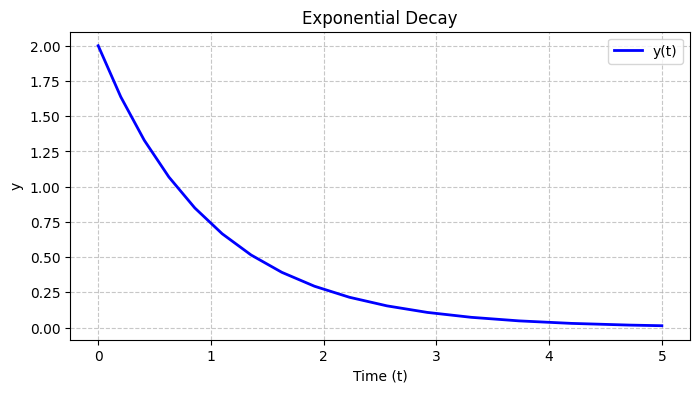

In [2]:
def exp_derivative(t, y):
    return -y

res_y, res_t = sd.RungeKutta(function=exp_derivative, t_min=0.0, t_max=5.0, initial_y=2.0)  

plt.figure(figsize=(8, 4))
plt.plot(res_t, res_y, label="y(t)", color="blue", linewidth=2)  
plt.title("Exponential Decay")
plt.xlabel("Time (t)")

plt.ylabel("y")
plt.grid(True, linestyle="--", alpha=0.7)
plt.legend()
plt.show()




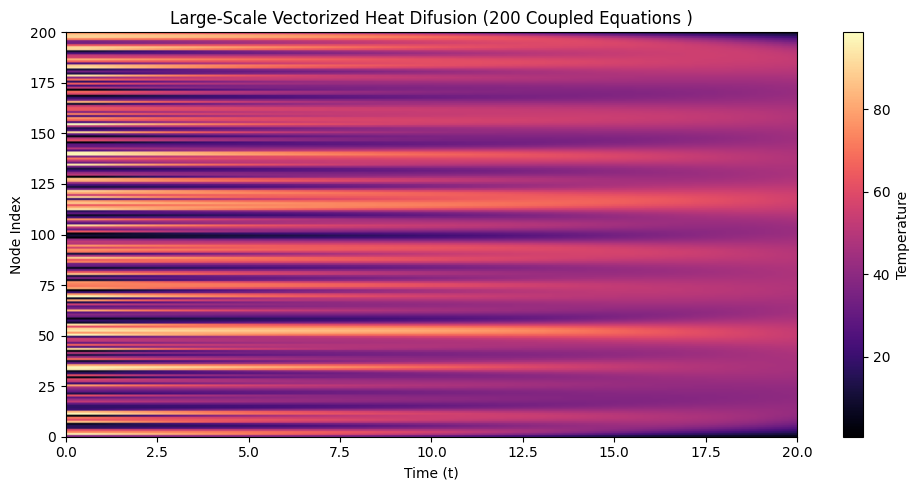

In [8]:
N = 200
A_matrix = np.diag(-2.0 * np.ones(N)) + np.diag(np.ones(N-1), 1) + np.diag(np.ones(N-1), -1)

def large_matrix_system(t, y):
    return A_matrix @ y

np.random.seed(42) 

initial_y = np.random.uniform(0, 100, size=N)

res_y, res_t = sd.RungeKutta( function=large_matrix_system,t_min=0.0,t_max=20.0,initial_y=initial_y,compile_to_C=True  ) 

plt.figure(figsize=(10, 5))

plt.imshow(res_y.T, aspect='auto', cmap='magma', origin='lower', extent=[res_t[0], res_t[-1], 0, N])

plt.colorbar(label="Temperature")
plt.title("Large-Scale Vectorized Heat Difusion (200 Coupled Equations )") 
plt.xlabel("Time (t)")
plt.ylabel("Node Index")
plt.tight_layout()
plt.show()

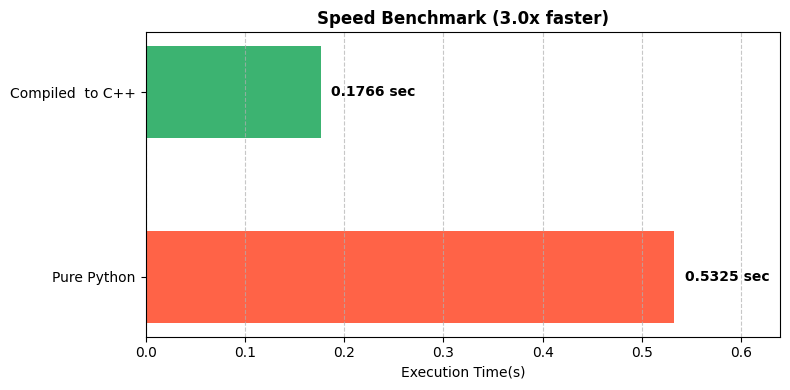

In [31]:
def heavy_system(t, y):
    return [
        1.5 * y[0] - 0.1 * y[0] * y[1],
        0.1 * y[0] * y[1] - 1.5 * y[1]
    ]

t_min, t_max = 0.0, 5000.0  
initial_y = [10.0, 5.0]


start_py = time.perf_counter()
res_y_py, res_t_py = sd.RungeKutta(function=heavy_system, t_min=t_min, t_max=t_max, initial_y=initial_y, compile_to_C=False)
time_python = time.perf_counter() - start_py


start_c = time.perf_counter()

res_y_c, res_t_c = sd.RungeKutta(function=heavy_system, t_min=t_min, t_max=t_max, initial_y=initial_y, compile_to_C=True)
time_c = time.perf_counter() - start_c



speedup = time_python / time_c

labels = ['Pure Python', 'Compiled  to C++']
times = [time_python, time_c]
colors = ['tomato', 'mediumseagreen']



plt.figure(figsize=(8, 4))
bars = plt.barh(labels, times, color=colors, height=0.5)

for bar in bars:
    plt.text(bar.get_width() + (max(times) * 0.02), bar.get_y() + bar.get_height()/2, f'{bar.get_width():.4f} sec', va='center', fontweight='bold')
plt.title(f"Speed Benchmark ({speedup:.1f}x faster)", fontweight='bold')
plt.xlabel("Execution Time(s)")
plt.xlim(0, max(times) * 1.2) 
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()